# 🧠 Self-Pruning Neural Network
### Tredence AI Engineering Intern — Case Study
**Dataset:** CIFAR-10 | **Task:** Image Classification with learnable weight pruning

---

## Cell 1 — Check GPU

In [1]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

CUDA available: True
GPU: Tesla T4
Using device: cuda


## Cell 2 — Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print('All imports successful ✅')

All imports successful ✅


## Cell 3 — PrunableLinear Layer
Each weight has a learnable gate. If gate → 0, the weight is pruned.

In [3]:
class PrunableLinear(nn.Module):
    """
    Custom linear layer with learnable gates.

    Forward pass:
        gates          = sigmoid(gate_scores)       in (0, 1)
        pruned_weights = weight * gates             element-wise
        output         = x @ pruned_weights.T + bias

    When gate ≈ 0  →  weight is effectively removed (pruned).
    Gradients flow through both weight and gate_scores automatically.
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Standard learnable weight & bias
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))

        # Learnable gate scores (same shape as weight)
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

        # Kaiming init for weights
        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates         = torch.sigmoid(self.gate_scores)   # squash to (0,1)
        pruned_weights = self.weight * gates              # element-wise mask
        return F.linear(x, pruned_weights, self.bias)     # standard linear op

    def get_gates(self) -> torch.Tensor:
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold=1e-2) -> float:
        gates = self.get_gates()
        return (gates < threshold).float().mean().item()


print('PrunableLinear defined ✅')

PrunableLinear defined ✅


## Cell 4 — Network Definition

In [4]:
class SelfPruningNet(nn.Module):
    """
    Feed-forward network for CIFAR-10.
    Architecture: 3072 → 1024 → 512 → 256 → 10
    All linear layers are PrunableLinear.
    """

    def __init__(self, dropout=0.3):
        super().__init__()

        self.prunable_layers = nn.ModuleList([
            PrunableLinear(3 * 32 * 32, 1024),
            PrunableLinear(1024,        512),
            PrunableLinear(512,         256),
            PrunableLinear(256,          10),
        ])

        self.bn1  = nn.BatchNorm1d(1024)
        self.bn2  = nn.BatchNorm1d(512)
        self.bn3  = nn.BatchNorm1d(256)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.drop(F.relu(self.bn1(self.prunable_layers[0](x))))
        x = self.drop(F.relu(self.bn2(self.prunable_layers[1](x))))
        x = self.drop(F.relu(self.bn3(self.prunable_layers[2](x))))
        x = self.prunable_layers[3](x)
        return x

    def sparsity_loss(self):
        """
        L1 norm of all gate values — penalises the network for keeping
        too many active connections. Encourages gates to go to exactly 0.
        """
        total = torch.tensor(0.0, device=next(self.parameters()).device)
        for layer in self.prunable_layers:
            total = total + torch.sigmoid(layer.gate_scores).sum()
        return total

    def overall_sparsity(self, threshold=1e-2):
        total, pruned = 0, 0
        for layer in self.prunable_layers:
            gates   = layer.get_gates()
            total  += gates.numel()
            pruned += (gates < threshold).sum().item()
        return pruned / total

    def all_gate_values(self):
        return np.concatenate([
            layer.get_gates().cpu().numpy().ravel()
            for layer in self.prunable_layers
        ])


print('SelfPruningNet defined ✅')

SelfPruningNet defined ✅


## Cell 5 — Load CIFAR-10

In [5]:
def get_cifar10_loaders(batch_size=256):
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_ds = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
    test_ds  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

    # num_workers=0 is required for Kaggle notebooks
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, test_loader


train_loader, test_loader = get_cifar10_loaders(batch_size=256)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)} ✅')

100%|██████████| 170M/170M [00:10<00:00, 15.5MB/s] 


Train batches: 196 | Test batches: 40 ✅


## Cell 6 — Training & Evaluation Functions

In [6]:
def train_one_epoch(model, loader, optimizer, lam, device):
    model.train()
    total_cls, total_spar, correct, n = 0.0, 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        logits    = model(imgs)
        cls_loss  = F.cross_entropy(logits, labels)
        spar_loss = model.sparsity_loss()
        loss      = cls_loss + lam * spar_loss

        loss.backward()
        optimizer.step()

        bs          = imgs.size(0)
        total_cls  += cls_loss.item()  * bs
        total_spar += spar_loss.item() * bs
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += bs

    return {'cls_loss': total_cls/n, 'spar_loss': total_spar/n,
            'train_acc': correct/n}


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, n = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        n       += imgs.size(0)
    return correct / n


print('Training functions defined ✅')

Training functions defined ✅


## Cell 7 — Train for All 3 Lambda Values
⏱️ **Expected time on Kaggle GPU: ~10–15 minutes total**

In [7]:
EPOCHS  = 30
LAMBDAS = [1e-5, 1e-4, 1e-3]   # low / medium / high sparsity
results = []

for lam in LAMBDAS:
    print(f'\n{"="*55}')
    print(f'  Training with λ = {lam}')
    print(f'{"="*55}')

    model     = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    for epoch in range(1, EPOCHS + 1):
        stats = train_one_epoch(model, train_loader, optimizer, lam, device)
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            test_acc = evaluate(model, test_loader, device)
            sparsity = model.overall_sparsity()
            print(f'  Epoch {epoch:3d}/{EPOCHS} | '
                  f'ClsLoss={stats["cls_loss"]:.4f} | '
                  f'TrainAcc={stats["train_acc"]*100:.1f}% | '
                  f'TestAcc={test_acc*100:.1f}% | '
                  f'Sparsity={sparsity*100:.1f}%')

    final_acc      = evaluate(model, test_loader, device)
    final_sparsity = model.overall_sparsity()
    gate_values    = model.all_gate_values()

    print(f'\n  ✅ λ={lam} → TestAcc={final_acc*100:.2f}%  Sparsity={final_sparsity*100:.2f}%')

    results.append({
        'lam':      lam,
        'test_acc': final_acc,
        'sparsity': final_sparsity,
        'gates':    gate_values,
    })

print('\n🎉 All runs complete!')


  Training with λ = 1e-05
  Epoch   1/30 | ClsLoss=1.8998 | TrainAcc=30.9% | TestAcc=41.4% | Sparsity=0.0%
  Epoch   5/30 | ClsLoss=1.5751 | TrainAcc=42.9% | TestAcc=49.0% | Sparsity=0.0%
  Epoch  10/30 | ClsLoss=1.4839 | TrainAcc=46.5% | TestAcc=52.1% | Sparsity=0.0%
  Epoch  15/30 | ClsLoss=1.4215 | TrainAcc=48.8% | TestAcc=54.3% | Sparsity=0.0%
  Epoch  20/30 | ClsLoss=1.3593 | TrainAcc=51.0% | TestAcc=55.9% | Sparsity=0.0%
  Epoch  25/30 | ClsLoss=1.3086 | TrainAcc=53.2% | TestAcc=57.1% | Sparsity=0.0%
  Epoch  30/30 | ClsLoss=1.2950 | TrainAcc=53.7% | TestAcc=57.8% | Sparsity=0.0%

  ✅ λ=1e-05 → TestAcc=57.76%  Sparsity=0.00%

  Training with λ = 0.0001
  Epoch   1/30 | ClsLoss=1.8926 | TrainAcc=30.8% | TestAcc=40.5% | Sparsity=0.0%
  Epoch   5/30 | ClsLoss=1.5728 | TrainAcc=43.4% | TestAcc=48.8% | Sparsity=0.0%
  Epoch  10/30 | ClsLoss=1.4831 | TrainAcc=46.4% | TestAcc=52.0% | Sparsity=0.0%
  Epoch  15/30 | ClsLoss=1.4227 | TrainAcc=48.8% | TestAcc=53.6% | Sparsity=0.0%
  Epoch 

## Cell 8 — Results Table

In [8]:
print('\n' + '='*55)
print(f"  {'Lambda':>10}  {'Test Accuracy':>15}  {'Sparsity Level':>15}")
print('='*55)
for r in results:
    print(f"  {r['lam']:>10}  {r['test_acc']*100:>14.2f}%  {r['sparsity']*100:>14.2f}%")
print('='*55)


      Lambda    Test Accuracy   Sparsity Level
       1e-05           57.76%            0.00%
      0.0001           57.82%            0.00%
       0.001           57.68%            0.00%


## Cell 9 — Gate Distribution Plot

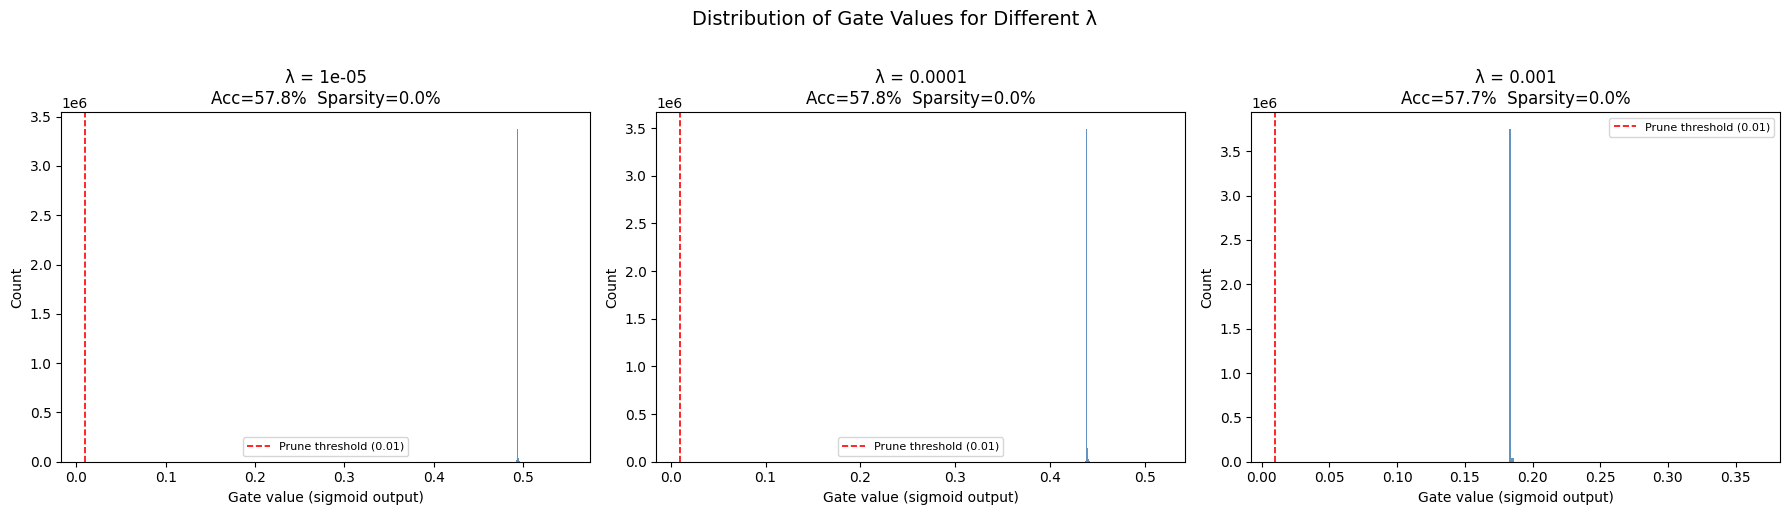

📊 Plot saved → gate_distribution.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res in zip(axes, results):
    ax.hist(res['gates'], bins=100, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(
        f"λ = {res['lam']}\n"
        f"Acc={res['test_acc']*100:.1f}%  "
        f"Sparsity={res['sparsity']*100:.1f}%",
        fontsize=12
    )
    ax.set_xlabel('Gate value (sigmoid output)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.axvline(0.01, color='red', linestyle='--', linewidth=1.2,
               label='Prune threshold (0.01)')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Gate Values for Different λ', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('gate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Plot saved → gate_distribution.png')

---
## ✅ Submission Checklist
- [ ] Code runs without errors
- [ ] Results table printed
- [ ] `gate_distribution.png` saved
- [ ] Upload to GitHub repo
- [ ] Share GitHub link with Tredence